# Regressão Linear com PyTorch - Dataset House Sales

## Objetivos

Este exemplo utiliza regressão linear com um novo dataset vindo do Kaggle (https://www.kaggle.com/datasets/harlfoxem/housesalesprediction).

Utiliza-se:
- a função de perda MSE do PyTorch,
- treinamento dos parâmetros via gradiente descendente usando o otimizador.
- A rede é criada com uma camada nn.Linear()
- Divisão entre dataset de treinamento e validação

## Importação dos pacotes

In [149]:
%matplotlib inline
import torch
from torch import nn, optim
from torch.autograd import Variable
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(1234)

## Leitura dos dados

In [150]:
#!/bin/bash
#!curl -L -o /content/housesalesprediction.zip\
#  https://www.kaggle.com/api/v1/datasets/download/harlfoxem/housesalesprediction

In [151]:
!ls #pra executar comandos linux precisa colocar a "!"

housesalesprediction.zip  kc_house_data.csv  sample_data


In [152]:
#!unzip /content/housesalesprediction.zip #precisa deszipar pra criar o arquivo .csv

In [153]:
# Load the dataset
df = pd.read_csv('kc_house_data.csv') #lendo o csv com o pandas

In [154]:
df.shape

(21613, 21)

In [155]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [156]:
# no X deve salvar todas as colunas exceto price que é o valor que devemos prever
X = df.drop('price', axis=1)
y = df[['price']].values

In [157]:
X[0:5] #features das casas

,id,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [158]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   bedrooms       21613 non-null  int64  
 3   bathrooms      21613 non-null  float64
 4   sqft_living    21613 non-null  int64  
 5   sqft_lot       21613 non-null  int64  
 6   floors         21613 non-null  float64
 7   waterfront     21613 non-null  int64  
 8   view           21613 non-null  int64  
 9   condition      21613 non-null  int64  
 10  grade          21613 non-null  int64  
 11  sqft_above     21613 non-null  int64  
 12  sqft_basement  21613 non-null  int64  
 13  yr_built       21613 non-null  int64  
 14  yr_renovated   21613 non-null  int64  
 15  zipcode        21613 non-null  int64  
 16  lat            21613 non-null  float64
 17  long           21613 non-null  float64
 18  sqft_l

In [159]:
#remove coluna date
X = df.drop('date', axis=1)

In [160]:
#remove a coluna id que não influencia no valor da casa
X = X.drop('id', axis=1)

In [161]:
y #preço das casas

array([[221900.],
       [538000.],
       [180000.],
       ...,
       [402101.],
       [400000.],
       [325000.]])

### Normalização dos dados

In [162]:
# Normalize X
x_scaler = StandardScaler()
X_scaled = x_scaler.fit_transform(X)

# Normalize y
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y)

In [163]:
# Split the normalized dataset into training and validation sets (70/30 split)
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_scaled, test_size=0.3, random_state=42)

# Convert numpy arrays to float tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32) #torch.FloatTensor
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)
print("X_val_tensor shape:", X_val_tensor.shape)
print("y_val_tensor shape:", y_val_tensor.shape)

X_train_tensor shape: torch.Size([15129, 19])
y_train_tensor shape: torch.Size([15129, 1])
X_val_tensor shape: torch.Size([6484, 19])
y_val_tensor shape: torch.Size([6484, 1])


## Criação do modelo da rede

In [164]:
model = torch.nn.Linear(X_train_tensor.shape[1], 1) # define o modelo considerando todas as features de X_train_tensor

### Verificando a inicialização dos parâmetros

In [165]:
model.weight.data

tensor([[-0.2161, -0.0450, -0.1102, -0.0612, -0.2027,  0.0921, -0.2056, -0.0146,
          0.0797, -0.0773,  0.1302,  0.0289,  0.1261,  0.1472, -0.1013,  0.0834,
         -0.0993,  0.0719, -0.1199]])

### Testando o predict da rede

In [166]:
# Test the model's prediction with a dummy input of correct shape (5 samples, 20 features)
model(torch.ones(5, X_train_tensor.shape[1]))

tensor([[-0.3875],
        [-0.3875],
        [-0.3875],
        [-0.3875],
        [-0.3875]], grad_fn=<AddmmBackward0>)

In [167]:
model(X_train_tensor[0:5])

tensor([[ 0.2665],
        [ 0.0858],
        [ 0.3503],
        [-1.9267],
        [-1.5374]], grad_fn=<AddmmBackward0>)

## Treinamento

### Definindo função de perda e otimizador

In [168]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)
num_epochs = 120

### Laço de treinamento

In [169]:
def train_epoch(model, optimizer, criterion, X_train, y_train):
    model.train() # Set model to training mode
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train) #predict
    loss = criterion(outputs, y_train)  #calculo das perdas

    # Backward and optimize (atualização dos pesos)
    loss.backward()
    optimizer.step()

    return loss.item() # Return scalar loss value (retorna o valor da perda)

In [170]:
def validate_epoch(model, criterion, X_val, y_val):
    model.eval() # Set model to evaluation mode
    with torch.no_grad(): # Disable gradient calculations
        outputs = model(X_val)
        loss = criterion(outputs, y_val)
    return loss.item() # Return scalar loss value

**Obs:** X_train e X_val influenciam os pesos, mas X_val e y_val não influenciam

In [171]:

train_losses = [] #perdas de treinamento
val_losses = [] #perdas de validação

for epoch in range(num_epochs):
    # Training step
    train_loss = train_epoch(model, optimizer, criterion, X_train_tensor, y_train_tensor)
    train_losses.append(train_loss)

    # Validation step
    val_loss = validate_epoch(model, criterion, X_val_tensor, y_val_tensor)
    val_losses.append(val_loss)

    # verbose
    if (epoch + 1) % 2 == 0:
        print(f'Epoch[{epoch+1}/{num_epochs}], Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}')

Epoch[2/120], Train Loss: 0.518728, Val Loss: 0.392339
Epoch[4/120], Train Loss: 0.270957, Val Loss: 0.248906
Epoch[6/120], Train Loss: 0.192398, Val Loss: 0.183725
Epoch[8/120], Train Loss: 0.147715, Val Loss: 0.142589
Epoch[10/120], Train Loss: 0.116824, Val Loss: 0.113272
Epoch[12/120], Train Loss: 0.093830, Val Loss: 0.091206
Epoch[14/120], Train Loss: 0.076096, Val Loss: 0.074101
Epoch[16/120], Train Loss: 0.062138, Val Loss: 0.060600
Epoch[18/120], Train Loss: 0.051010, Val Loss: 0.049814
Epoch[20/120], Train Loss: 0.042054, Val Loss: 0.041120
Epoch[22/120], Train Loss: 0.034797, Val Loss: 0.034064
Epoch[24/120], Train Loss: 0.028883, Val Loss: 0.028306
Epoch[26/120], Train Loss: 0.024040, Val Loss: 0.023586
Epoch[28/120], Train Loss: 0.020059, Val Loss: 0.019700
Epoch[30/120], Train Loss: 0.016775, Val Loss: 0.016490
Epoch[32/120], Train Loss: 0.014056, Val Loss: 0.013830
Epoch[34/120], Train Loss: 0.011800, Val Loss: 0.011620
Epoch[36/120], Train Loss: 0.009923, Val Loss: 0.009

**Melhorias: 1) verificar a época a partir da qual os valores se estabilizam (melhor época). 2) "paciência" - esperar determinada qtn de épocas, e se a partir dali os pesos não tiverem uma alteração significativa, poderia interromper o treinamento.**

## Avaliação

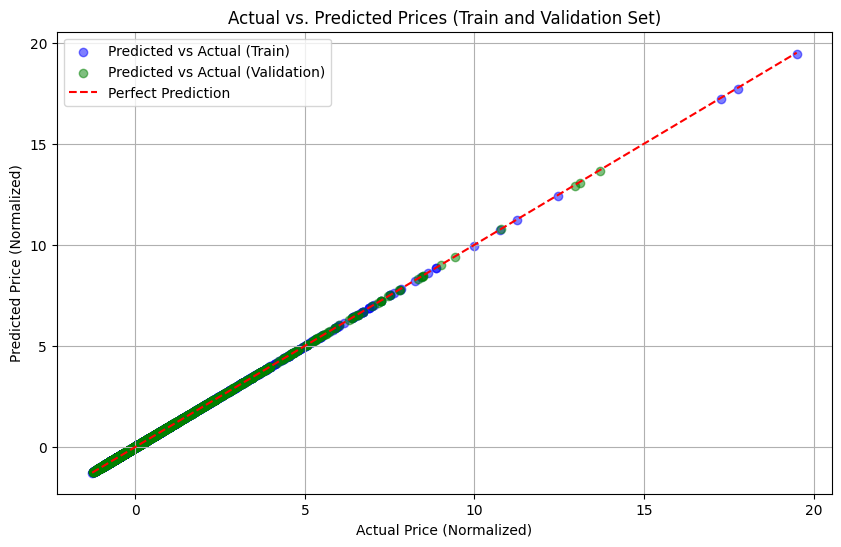

In [172]:
y_pred_train = model(X_train_tensor)
y_pred_val = model(X_val_tensor)

plt.figure(figsize=(10, 6))

# Plot predicted vs actual for Training Data
plt.scatter(y_train_tensor.numpy(), y_pred_train.data.numpy(), alpha=0.5, label='Predicted vs Actual (Train)', color='blue')

# Plot predicted vs actual for Validation Data
plt.scatter(y_val_tensor.numpy(), y_pred_val.data.numpy(), alpha=0.5, label='Predicted vs Actual (Validation)', color='green')

# Plot a perfect prediction line (y=x)
max_val = max(y_val_tensor.max(), y_pred_val.max(), y_train_tensor.max(), y_pred_train.max()).item()
min_val = min(y_val_tensor.min(), y_pred_val.min(), y_train_tensor.min(), y_pred_train.min()).item()
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')

plt.xlabel('Actual Price (Normalized)')
plt.ylabel('Predicted Price (Normalized)')
plt.title('Actual vs. Predicted Prices (Train and Validation Set)')
plt.legend()
plt.grid(True)
plt.show()

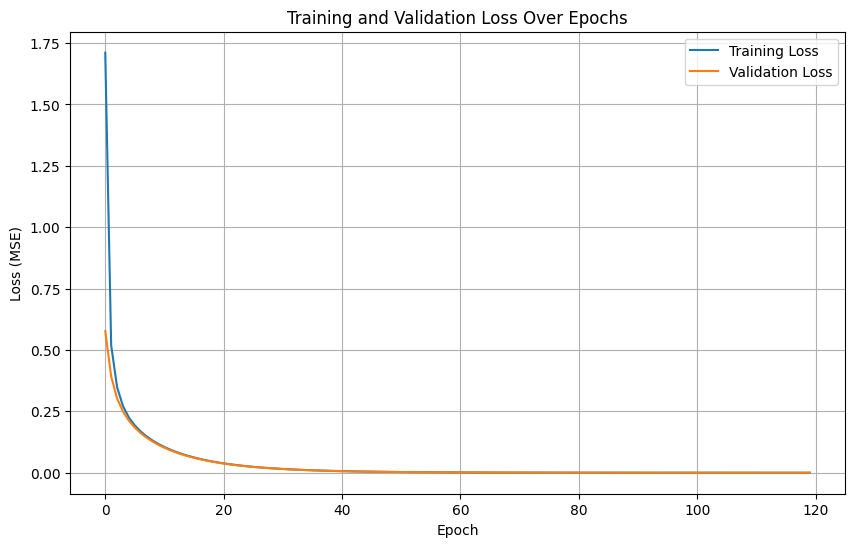

In [173]:
plt.figure(figsize=(10, 6))
plt.plot(range(num_epochs), train_losses, label='Training Loss')
plt.plot(range(num_epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()